# Two July 2024 Events: SFL 240714 and Candidate BC 240711

Light curves for two events BurstCube recorded in July 2024:

* **SFL 240714** -- a solar flare on 2024-07-14 around 02:30 UTC, which
  Fermi GBM also triggered on.
* **BC 240711** -- a BurstCube candidate transient at 2024-07-11 00:20:20
  UTC, with no GBM trigger.

These are not arbitrary picks. Of the 3 attitude epochs that exist in the
whole archive (notebook 3; archive caveat #1), epochs 1 and 2 are the manual
reconstructions made for exactly these two events -- epoch 0 is GRB
240629A (notebook 4). The attitude is marked on the plots below but not used
further; this notebook is about the light curves.

Every plot puts BurstCube MET on the bottom axis and UTC on the top axis,
each with its own ticks at round values. The UTC axis uses the **corrected** MET epoch,
2021-01-01 00:00:00 TAI; the epoch the archive's own headers state is 37 s
wrong (README Caveats: *The archive's MET epoch is stated wrong by 37
seconds*). The MET axis is simply the value in the files, which is not
affected by that correction.

Light curves are split into two energy bands taken from the CALDB channel
boundaries -- CBD channels 2-5 (~62-316 keV) and 6-15 (~316-1600 keV) --
and channels 0-1 are left out; the BC 240711 section explains why. Only
cleaned (`_cl`) CBD is used. Neither day has TTE.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator
import astropy.units as u
from astropy.time import Time as AstroTime

from gdt.core import data_path
from gdt.missions.burstcube import caldb
from gdt.missions.burstcube.cbd import BurstCubeCBD
from gdt.missions.burstcube.hk import BurstCubeHK
from gdt.missions.burstcube.time import Time as BCTime
from gdt.missions.burstcube.finders import BurstCubeObsFinder, BurstCubeTrendFinder
from gdt.missions.burstcube.attitude import BurstCubeAttitude

from gdt.missions.fermi.gbm.catalogs import TriggerCatalog
from gdt.missions.fermi.gbm.detectors import GbmDetectors
from gdt.missions.fermi.gbm.finders import TriggerFinder
from gdt.missions.fermi.gbm.phaii import Ctime

# Every archive file's own header states a MET epoch 37 s later than the
# truth, so each open() warns (README Caveats). The corrected TAI epoch is
# applied either way; silenced here for readable output.
warnings.filterwarnings('ignore', message=".*state an epoch of.*")

DETECTORS = ['CS0', 'CS1', 'CS2', 'CS3']
SOFT, HARD = slice(2, 6), slice(6, 16)
%matplotlib inline

## Shared pieces

**Energy bands.** The keV range of each band is read from CALDB for each
detector rather than written in by hand; it differs slightly between
detectors.

**Binning.** CBD's native 0.256 s bins are too noisy to show a signal
~15% above background, so both events are shown on coarser bins. Rather than
`rebin_time` -- which notebook 1 shows failing on the archive's genuine
1 ms-short bins -- each 0.256 s bin is assigned to the coarse bin containing
its centre, and counts and exposure are summed there. A coarse bin whose
summed exposure is under half its width is treated as a gap.

**Axes.** `add_utc_axis` puts a UTC axis on top of a plot whose bottom axis
is MET. No leap second fell during the mission, so UTC seconds since
midnight differ from MET by a constant; the top axis is just that shift, with
its own ticks at round UTC times, anchored through the corrected epoch.

In [2]:
def band_label(channels):
    lows, highs = [], []
    for det in DETECTORS:
        eb = caldb.ebounds(det, 16)
        lows.append(eb.low_edges()[channels.start])
        highs.append(eb.high_edges()[channels.stop - 1])
    return f'{min(lows):.0f}-{max(highs):.0f} keV'


def load_cbds(obs_id):
    download_dir = Path(data_path) / 'burstcube' / obs_id
    download_dir.mkdir(parents=True, exist_ok=True)
    finder = BurstCubeObsFinder()
    finder.cd(obs_id)
    paths = finder.get_cbd(download_dir, detectors=DETECTORS, variant='cl', verbose=False)
    return {det: BurstCubeCBD.open(path) for det, path in zip(DETECTORS, paths)}


def coarse_rates(cbds, edges, channels):
    # All 4 detectors share bin edges (notebook 4 checks this), so one
    # detector's times and exposure serve for all of them.
    ref = cbds['CS0'].data
    centre = 0.5 * (ref.tstart + ref.tstop)
    idx = np.searchsorted(edges, centre) - 1
    ok = (idx >= 0) & (idx < edges.size - 1)
    n = edges.size - 1
    exposure = np.bincount(idx[ok], weights=ref.exposure[ok], minlength=n)
    covered = exposure > 0.5 * np.diff(edges)
    rates = {}
    for det, cbd in cbds.items():
        counts = cbd.data.counts[:, channels].sum(axis=1)
        summed = np.bincount(idx[ok], weights=counts[ok], minlength=n)
        rates[det] = np.where(covered, summed / np.where(covered, exposure, 1.0), np.nan)
    rates['sum'] = sum(rates[det] for det in DETECTORS)
    return rates


def covered_span(cbds, t0, max_half_width):
    # The gap-free stretch of _cl data around t0, capped at +/-max_half_width.
    ref = cbds['CS0'].data
    start, stop = ref.tstart, ref.tstop
    j = int(np.searchsorted(stop, t0))
    lo = j
    while lo > 0 and start[lo] - stop[lo - 1] < 1.0 and t0 - start[lo - 1] < max_half_width:
        lo -= 1
    hi = j
    while hi < stop.size - 1 and start[hi + 1] - stop[hi] < 1.0 and stop[hi + 1] - t0 < max_half_width:
        hi += 1
    return start[lo], stop[hi]


def hms(seconds, pos=None):
    s = int(round(seconds))
    return f'{s // 3600:02d}:{s % 3600 // 60:02d}:{s % 60:02d}'


def add_utc_axis(ax):
    lo, hi = ax.get_xlim()
    day = BCTime(0.5 * (lo + hi), format='burstcube').utc.strftime('%Y-%m-%d')
    midnight = BCTime(f'{day}T00:00:00', scale='utc').burstcube
    top = ax.secondary_xaxis('top', functions=(lambda met: met - midnight,
                                               lambda sec: sec + midnight))
    step = next(b for b in (10, 30, 60, 120, 300, 600, 900, 1800, 3600)
                if (hi - lo) / b <= 8)
    top.xaxis.set_major_locator(MultipleLocator(step))
    top.xaxis.set_major_formatter(FuncFormatter(hms))
    top.set_xlabel(f'UTC on {day} (corrected MET epoch)')
    return top


def plot_bands(axes, edges, soft, hard):
    centres = 0.5 * (edges[:-1] + edges[1:])
    for ax, rates, label in ((axes[0], soft, band_label(SOFT)),
                             (axes[1], hard, band_label(HARD))):
        for det in DETECTORS:
            ax.step(centres, rates[det], where='mid', lw=0.7, label=det)
        ax.step(centres, rates['sum'], where='mid', lw=1.4, color='k', label='sum')
        ax.set_ylabel(f'{label}\n(ct/s)')
    axes[0].legend(ncol=5, fontsize=8, loc='upper left')


def plot_syst_error(ax, cbds, span):
    cbd = cbds['CS0']
    keep = (cbd.data.tstop >= span[0]) & (cbd.data.tstart <= span[1])
    ax.step(cbd.data.tstop[keep], cbd.time_syst_error[keep], where='pre', color='C7')
    ax.set_ylabel('TIME_SYST_ERROR\n(s)')
    ax.set_ylim(0, 1.6 * np.nanmax(cbd.time_syst_error[keep]))


def mark(axes, met, label, row=0, **style):
    for ax in axes:
        ax.axvline(met, **style)
    axes[0].annotate(label, xy=(met, 1), xycoords=('data', 'axes fraction'),
                     xytext=(3, -12 - 11 * row), textcoords='offset points',
                     fontsize=8, color=style.get('color', 'k'))


def finish_met_axis(ax):
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
    ax.set_xlabel('BurstCube MET (s)')


trend_dir = Path(data_path) / 'burstcube' / 'trend'
att = BurstCubeAttitude.open(BurstCubeTrendFinder().get_attitude(trend_dir))
for i in range(att.num_rows):
    print(f'attitude epoch {i}: MET {att.time[i].burstcube:.3f} = '
         f'{att.time[i].utc.isot} UTC')

Output()

attitude epoch 0: MET 110220808.000 = 2024-06-29T16:52:51.000 UTC
attitude epoch 1: MET 111198020.000 = 2024-07-11T00:19:43.000 UTC
attitude epoch 2: MET 111465000.000 = 2024-07-14T02:29:23.000 UTC


## SFL 240714

### The GBM trigger

GBM's trigger catalog classifies each trigger; solar flares are `SFLARE`.
Rather than hardcode a trigger number, this looks for the GBM flare trigger
nearest 02:30 UTC on 2024-07-14.

In [3]:
trigger_cat = TriggerCatalog()
table = trigger_cat.get_table(columns=('trigger_name', 'trigger_time',
                                       'trigger_type', 'detector_mask'))
approx = AstroTime('2024-07-14T02:30:00', scale='utc')
is_flare = np.char.strip(table['TRIGGER_TYPE'].astype(str)) == 'SFLARE'
same_day = np.abs(table['TRIGGER_TIME'] - approx.mjd) < 0.5
candidates = table[is_flare & same_day]
for row in candidates:
    print(f"{row['TRIGGER_NAME'].strip()}  "
         f"{AstroTime(row['TRIGGER_TIME'], format='mjd', scale='utc').isot}  SFLARE")

flare = candidates[np.argmin(np.abs(candidates['TRIGGER_TIME'] - approx.mjd))]
flare_name = flare['TRIGGER_NAME'].strip()
flare_utc = AstroTime(flare['TRIGGER_TIME'], format='mjd', scale='utc')
flare_dets = [det.name for det in GbmDetectors
             if flare['DETECTOR_MASK'][det.value[1]] == '1']
sfl_t0 = BCTime(flare_utc).burstcube
print(f'\nusing {flare_name}: {flare_utc.isot} UTC = BurstCube MET {sfl_t0:.3f}, '
     f'triggered detectors {flare_dets}')
print(f'attitude epoch 2 is {att.time[2].burstcube - sfl_t0:+.1f} s from this trigger '
     f'(corrected epoch)')

Sending request and awaiting response from HEASARC...


Finished in 5 s
bn240713813  2024-07-13T19:30:33.559  SFLARE
bn240714502  2024-07-14T12:02:57.497  SFLARE
bn240714172  2024-07-14T04:08:04.751  SFLARE
bn240714104  2024-07-14T02:29:20.244  SFLARE
bn240713956  2024-07-13T22:56:09.473  SFLARE
bn240713633  2024-07-13T15:12:07.621  SFLARE

using bn240714104: 2024-07-14T02:29:20.244 UTC = BurstCube MET 111464997.244, triggered detectors ['n3', 'n5']
attitude epoch 2 is +2.8 s from this trigger (corrected epoch)


### Data

BurstCube CBD for the day, and GBM's own data for the triggered detectors.
For GRB 240629A notebook 4 used GBM TTE, but a bright flare's TTE is huge:
for this trigger the two files together are ~950 MB, against ~15 MB for the
GRB. GBM's CTIME (0.256 s, 8 channels) is ~0.6 MB per detector and ample
for structure lasting tens of seconds, so it is used here instead. Its
channels are placed onto the same coarse bins as BurstCube's, by bin centre.

In [4]:
sfl_cbds = load_cbds('240714')

gbm_dir = Path(data_path) / 'fermi_gbm' / flare_name
gbm_dir.mkdir(parents=True, exist_ok=True)
ctime_paths = TriggerFinder(flare_name[2:]).get_ctime(gbm_dir, dets=flare_dets, verbose=False)
ctimes = {det: Ctime.open(path) for det, path in zip(flare_dets, ctime_paths)}
for det, ctime in ctimes.items():
    eb = ctime.ebounds
    print(f'GBM {det} CTIME channels (keV): '
         + ', '.join(f'{lo:.0f}-{hi:.0f}' for lo, hi in zip(eb.low_edges(), eb.high_edges())))

sfl_span = covered_span(sfl_cbds, sfl_t0, 1000.0)
print(f'\nBurstCube _cl coverage around the trigger: {sfl_span[0]-sfl_t0:+.0f} to '
     f'{sfl_span[1]-sfl_t0:+.0f} s (SAA passages on either side)')

GBM n3 CTIME channels (keV): 4-11, 11-27, 27-50, 50-102, 102-296, 296-539, 539-982, 982-2000
GBM n5 CTIME channels (keV): 4-11, 11-26, 26-50, 50-101, 101-295, 295-539, 539-984, 984-2000

BurstCube _cl coverage around the trigger: -626 to +874 s (SAA passages on either side)


GBM's channels 3-4 (~50-296 keV) cover almost exactly BurstCube's soft band,
so that is the like-for-like comparison. GBM's channels 0-2 (~4-50 keV) sit
below BurstCube's ~62 keV threshold entirely; they are shown too, because
that is where almost all of a flare's emission is.

During the brightest part of the flare GBM's detectors are swamped: the
livetime GBM records for a bin falls below half the bin. The cell below
finds where, from GBM's own exposure column, and those bins are masked
rather than plotted as rates.

In [5]:
def gbm_rates(ctime, edges, channels, t0_met):
    # GBM times are relative to its own trigger; shift them onto BurstCube MET.
    start = ctime.data.tstart + t0_met
    stop = ctime.data.tstop + t0_met
    width = stop - start
    live = np.divide(ctime.data.exposure, width, out=np.zeros_like(width), where=width > 0)
    good = np.isfinite(live) & (live >= 0.5)
    idx = np.searchsorted(edges, 0.5 * (start + stop)) - 1
    ok = good & (idx >= 0) & (idx < edges.size - 1)
    n = edges.size - 1
    counts = np.bincount(idx[ok], weights=ctime.data.counts[ok][:, channels].sum(axis=1), minlength=n)
    exposure = np.bincount(idx[ok], weights=ctime.data.exposure[ok], minlength=n)
    covered = exposure > 0.25 * np.diff(edges)
    return np.where(covered, counts / np.where(covered, exposure, 1.0), np.nan), start[~good], stop[~good]

GBM_MATCHED, GBM_THERMAL = slice(3, 5), slice(0, 3)
for det, ctime in ctimes.items():
    _, lo, hi = gbm_rates(ctime, np.array([sfl_span[0], sfl_span[1]]), GBM_MATCHED, sfl_t0)
    if lo.size:
        print(f'GBM {det}: livetime below 50% between {lo.min()-sfl_t0:+.0f} and '
             f'{hi.max()-sfl_t0:+.0f} s rel. trigger ({lo.size} CTIME bins)')

GBM n3: livetime below 50% between +134 and +598 s rel. trigger (1511 CTIME bins)
GBM n5: livetime below 50% between +77 and +615 s rel. trigger (8185 CTIME bins)


### The peak of the non-thermal burst

Where does GBM's 50-296 keV emission peak? Only a detector whose livetime
stays above 50% through the peak can say: once a bin is masked, the highest
remaining bin just marks where the mask starts, not where the emission
turns over. The cell below takes the detector whose livetime survives
longest, finds its highest 1.024 s bin, and checks how far that moves with
the bin width.

In [6]:
peak_det = max(ctimes, key=lambda det: gbm_rates(ctimes[det], np.array([sfl_span[0], sfl_span[1]]),
                                                 GBM_MATCHED, sfl_t0)[1].min())
for det, ctime in ctimes.items():
    first_masked = gbm_rates(ctime, np.array([sfl_span[0], sfl_span[1]]), GBM_MATCHED, sfl_t0)[1]
    first_masked = first_masked[first_masked > sfl_t0].min() - sfl_t0
    print(f'GBM {det}: livetime first below 50% at {first_masked:+.1f} s rel. trigger')

def gbm_peak(width):
    pedges = np.arange(sfl_t0 - 100.0, sfl_t0 + 300.0, width)
    rate = gbm_rates(ctimes[peak_det], pedges, GBM_MATCHED, sfl_t0)[0]
    k = np.nanargmax(rate)
    return 0.5 * (pedges[k] + pedges[k + 1]), rate[k]

sfl_peak, peak_rate = gbm_peak(1.024)
print(f'\nGBM {peak_det} ~50-296 keV peak (1.024 s bins): {peak_rate:.0f} ct/s at '
     f'{sfl_peak - sfl_t0:+.2f} s rel. trigger')
print(f'   = {BCTime(sfl_peak, format="burstcube").utc.isot} UTC = BurstCube MET {sfl_peak:.3f}')
for width in (0.256, 2.048, 4.096):
    print(f'   with {width:.3f} s bins: {gbm_peak(width)[0] - sfl_t0:+.2f} s')

GBM n3: livetime first below 50% at +133.7 s rel. trigger
GBM n5: livetime first below 50% at +76.7 s rel. trigger

GBM n3 ~50-296 keV peak (1.024 s bins): 5169 ct/s at +109.41 s rel. trigger
   = 2024-07-14T02:31:09.652 UTC = BurstCube MET 111465106.652
   with 0.256 s bins: +109.28 s
   with 2.048 s bins: +109.92 s
   with 4.096 s bins: +110.94 s


The other detector's livetime drops below 50% while the burst is still
rising, so it cannot place the peak. The peak found here moves by under 2 s
with the bin width. It is marked as a dotted line in the light curves below.

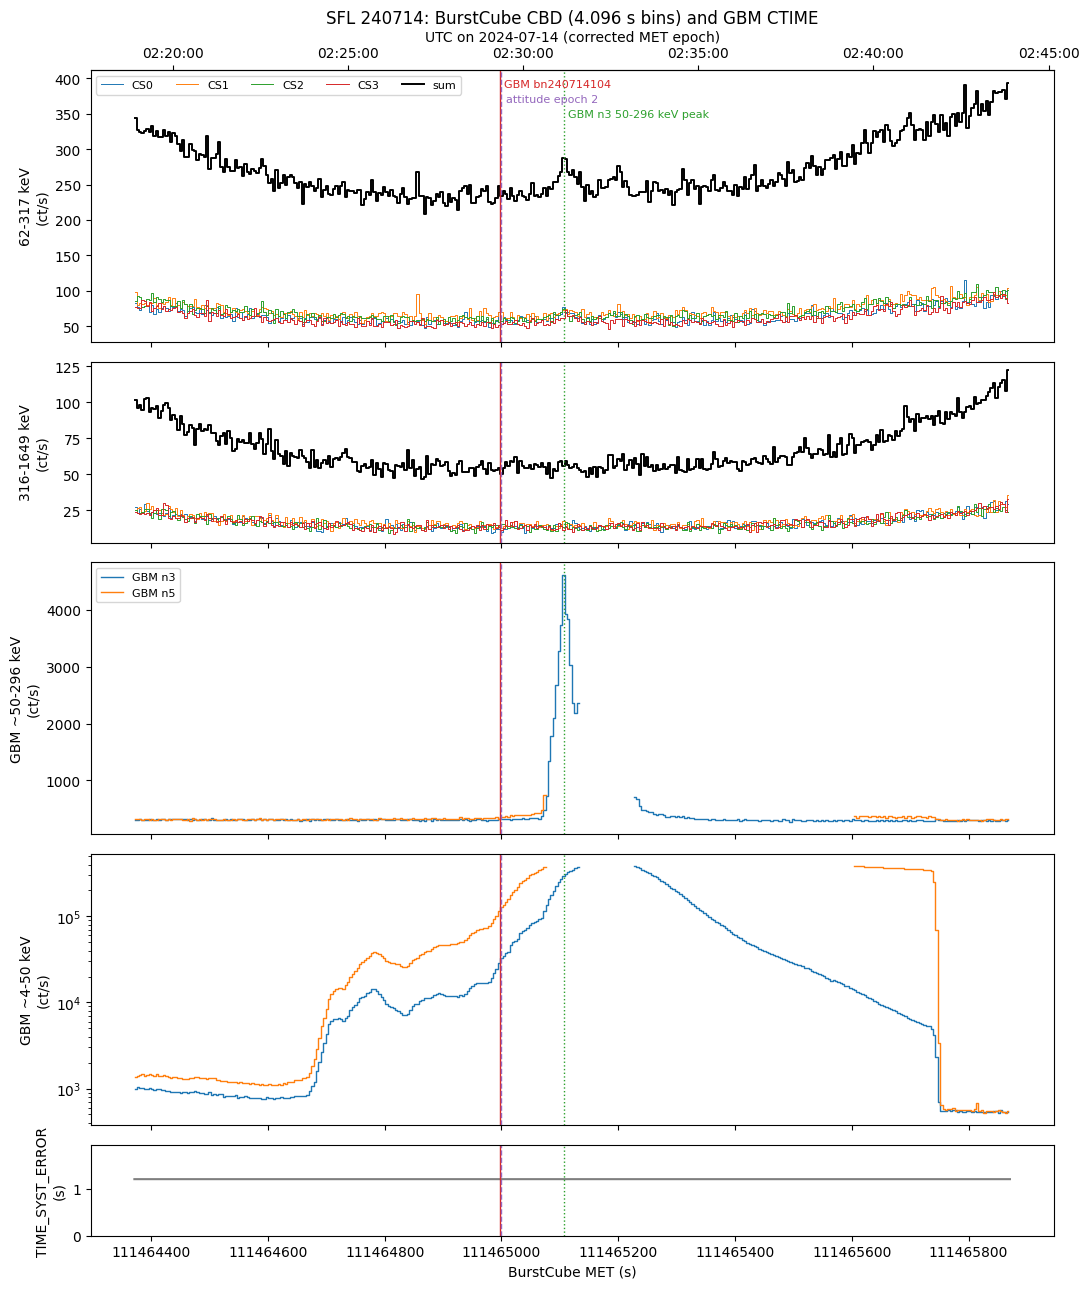

In [7]:
edges = np.arange(sfl_span[0], sfl_span[1], 4.096)
soft = coarse_rates(sfl_cbds, edges, SOFT)
hard = coarse_rates(sfl_cbds, edges, HARD)
centres = 0.5 * (edges[:-1] + edges[1:])

fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True,
                         height_ratios=(3, 2, 3, 3, 1))
plot_bands(axes[:2], edges, soft, hard)

for det, ctime in ctimes.items():
    matched, _, _ = gbm_rates(ctime, edges, GBM_MATCHED, sfl_t0)
    thermal, _, _ = gbm_rates(ctime, edges, GBM_THERMAL, sfl_t0)
    axes[2].step(centres, matched, where='mid', lw=1.0, label=f'GBM {det}')
    axes[3].step(centres, thermal, where='mid', lw=1.0, label=f'GBM {det}')
axes[2].set_ylabel('GBM ~50-296 keV\n(ct/s)')
axes[3].set_ylabel('GBM ~4-50 keV\n(ct/s)')
axes[3].set_yscale('log')
axes[2].legend(fontsize=8, loc='upper left')

plot_syst_error(axes[4], sfl_cbds, sfl_span)
mark(axes, sfl_t0, f'GBM {flare_name}', color='C3', lw=1.0)
mark(axes, att.time[2].burstcube, 'attitude epoch 2', row=1, color='C4', lw=1.0, ls='--')
mark(axes, sfl_peak, f'GBM {peak_det} 50-296 keV peak', row=2, color='C2', lw=1.0, ls=':')

axes[0].set_title('SFL 240714: BurstCube CBD (4.096 s bins) and GBM CTIME', pad=34)
finish_met_axis(axes[-1])
add_utc_axis(axes[0])
fig.tight_layout()
plt.show()

Reading from the bottom up:

* GBM's 4-50 keV panel is the flare as most instruments see it: thermal
  emission rising for minutes before the trigger and staying enormous
  afterwards. The gaps are where GBM's own livetime collapses, not missing
  data. The sharp drop in both GBM detectors about 12 minutes after the
  trigger is far too fast to be the flare fading; something changed in GBM's
  view of the Sun (the Sun setting behind the Earth for Fermi is one
  possibility), which this notebook does not investigate.
* In GBM's 50-296 keV band the flare is a short impulsive burst tens of
  seconds after the trigger -- the non-thermal hard X-rays.
* BurstCube's 62-316 keV band shows a modest bump at the same time, on top
  of a background curved by the SAA passages on either side of this window.
  BurstCube's threshold (~62 keV) puts the thermal emission out of its reach,
  so the non-thermal burst is the only part of the flare it can see.
* BurstCube's 316-1600 keV band shows nothing obvious; neither does much of
  GBM above ~300 keV.

The next cell zooms in on the impulsive phase and compares the two
like-for-like bands directly.

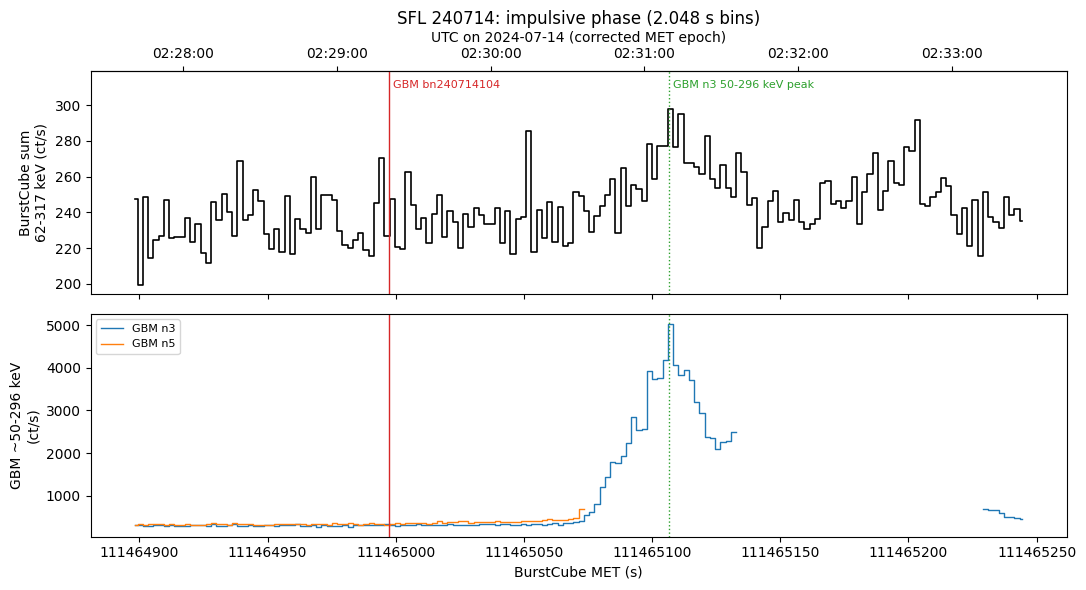

In [8]:
zoom = (sfl_t0 - 100.0, sfl_t0 + 250.0)
zedges = np.arange(zoom[0], zoom[1], 2.048)
zc = 0.5 * (zedges[:-1] + zedges[1:])
bc_soft = coarse_rates(sfl_cbds, zedges, SOFT)['sum']

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].step(zc, bc_soft, where='mid', color='k', lw=1.2)
axes[0].set_ylabel(f'BurstCube sum\n{band_label(SOFT)} (ct/s)')
for det, ctime in ctimes.items():
    axes[1].step(zc, gbm_rates(ctime, zedges, GBM_MATCHED, sfl_t0)[0],
                 where='mid', lw=1.0, label=f'GBM {det}')
axes[1].set_ylabel('GBM ~50-296 keV\n(ct/s)')
axes[1].legend(fontsize=8, loc='upper left')
mark(axes, sfl_t0, f'GBM {flare_name}', color='C3', lw=1.0)
mark(axes, sfl_peak, f'GBM {peak_det} 50-296 keV peak', color='C2', lw=1.0, ls=':')
bottom, top = axes[0].get_ylim()
axes[0].set_ylim(bottom, top + 0.15 * (top - bottom))  # room for the labels
axes[0].set_title('SFL 240714: impulsive phase (2.048 s bins)', pad=34)
finish_met_axis(axes[-1])
add_utc_axis(axes[0])
fig.tight_layout()
plt.show()

How well do the two line up in time? The cell below cross-correlates
BurstCube's background-subtracted soft-band sum with GBM's matched band over
the impulsive phase, shifting BurstCube by whole seconds. The GBM detector
used is the one whose livetime survives the longest into the impulsive
phase. A positive lag means BurstCube's features arrive later.

In [9]:
fedges = np.arange(sfl_t0 - 300.0, sfl_t0 + 400.0, 1.024)
fc = 0.5 * (fedges[:-1] + fedges[1:]) - sfl_t0
bc = coarse_rates(sfl_cbds, fedges, SOFT)['sum']
quiet = (((fc > -300) & (fc < -20)) | ((fc > 250) & (fc < 400))) & np.isfinite(bc)
bc_excess = bc - np.polyval(np.polyfit(fc[quiet], bc[quiet], 2), fc)

best_det, best_gbm = None, None
for det, ctime in ctimes.items():
    g = gbm_rates(ctime, fedges, GBM_MATCHED, sfl_t0)[0]
    if best_gbm is None or np.isfinite(g[(fc > 0) & (fc < 150)]).sum() > \
            np.isfinite(best_gbm[(fc > 0) & (fc < 150)]).sum():
        best_det, best_gbm = det, g
gbm_excess = best_gbm - np.nanmedian(best_gbm[(fc > -300) & (fc < -20)])

window = (fc > -40) & (fc < 135) & np.isfinite(gbm_excess)
lags = np.arange(-60, 61)
corr = []
for lag in lags:
    a = np.interp(fc[window] + lag, fc, bc_excess)
    b = gbm_excess[window]
    a, b = a - a.mean(), b - b.mean()
    corr.append(np.sum(a * b) / np.sqrt(np.sum(a * a) * np.sum(b * b)))
corr = np.array(corr)
best = lags[np.argmax(corr)]
width = lags[corr > corr.max() - 0.5 * (corr.max() - np.median(corr))]

print(f'GBM detector used: {best_det}')
print(f'peak correlation r={corr.max():.2f} at lag {best:+d} s; '
     f'within half the peak height from {width.min():+d} to {width.max():+d} s')
for lag in (-37, 0, 37):
    print(f'   r at lag {lag:+d} s: {corr[lags == lag][0]:+.2f}')

GBM detector used: n3
peak correlation r=0.68 at lag +5 s; within half the peak height from -17 to +22 s
   r at lag -37 s: +0.10
   r at lag +0 s: +0.63
   r at lag +37 s: -0.01


The correlation is high near zero lag and gone at +/-37 s. Converted with
the epoch the archive's headers state, BurstCube's burst would have landed
37 s after GBM's, where the correlation is nil. So this flare is a second,
independent confirmation of the corrected MET epoch -- after GRB 240629A in
notebook 4, and on a different day in a different time-correction regime.

What it cannot do is measure a residual of a few seconds. The correlation
peak is tens of seconds wide, because the impulsive phase itself is.
Notebook 4's GRB, which is much sharper, remains the precise measurement.

## BC 240711

### No GBM trigger

The same catalog shows whether GBM triggered on anything near the candidate.

In [10]:
bc_utc = AstroTime('2024-07-11T00:20:20', scale='utc')
near = np.abs(table['TRIGGER_TIME'] - bc_utc.mjd) * 86400.0 < 3 * 3600.0
for row in table[near]:
    t = AstroTime(row['TRIGGER_TIME'], format='mjd', scale='utc')
    print(f"{row['TRIGGER_NAME'].strip()}  {t.isot} UTC  "
         f"{row['TRIGGER_TYPE'].strip():8s} {(t - bc_utc).sec/60:+.1f} min from the candidate")

bn240711048  2024-07-11T01:09:37.806 UTC  SFLARE   +49.3 min from the candidate


Within three hours GBM triggered once, on a solar flare 49 minutes later --
not this event. So BC 240711 has no external detection to line up against.

### Which instant?

On the corrected epoch, attitude epoch 1 -- the reconstruction made for
this candidate -- sits at 00:19:43 UTC, 37 s before the quoted 00:20:20.
Converted with the epoch the archive's headers state, the same MET would read
00:20:20 exactly. So if the quoted time was itself derived from BurstCube
MET using the header epoch, the true instant is 00:19:43; if it came from
elsewhere, it is 00:20:20. Nothing here settles which, so both are marked.

In [11]:
bc_cbds = load_cbds('240711')
header = bc_cbds['CS0'].headers['CBD']
header_epoch = AstroTime(header['MJDREFI'] + header['MJDREFF'], format='mjd',
                         scale=header['TIMESYS'].lower())

bc_t0 = BCTime(bc_utc).burstcube
att1 = att.time[1].burstcube
print(f'quoted 00:20:20 UTC                         = MET {bc_t0:.3f}')
print(f'attitude epoch 1, MET {att1:.3f}          = '
     f'{att.time[1].utc.strftime("%H:%M:%S")} UTC on the corrected epoch '
     f'({att1 - bc_t0:+.1f} s)')
print(f'the same MET read with the header\'s epoch   = '
     f'{(header_epoch + att1 * u.s).utc.strftime("%H:%M:%S")} UTC')

quoted 00:20:20 UTC                         = MET 111198057.000
attitude epoch 1, MET 111198020.000          = 00:19:43 UTC on the corrected epoch (-37.0 s)
the same MET read with the header's epoch   = 00:20:20 UTC


### Why channels 0-1 are left out

On 240714 CBD channels 0-1 (below ~62 keV) are empty, as on most days after
the mid-mission threshold change. On 240711 they are not. Detector
housekeeping shows why: the change was still being tried out, and at the
time of the candidate the detectors were on the old, low thresholds.

In [12]:
hk_dir = Path(data_path) / 'burstcube' / '240711'
finder = BurstCubeObsFinder()
finder.cd('240711')
hk = BurstCubeHK.open(finder.get_hk(hk_dir, verbose=False))
hk_met = np.asarray(hk.hk2.time.burstcube)
thresholds = hk.base_threshold()
row = np.searchsorted(hk_met, bc_t0) - 1
print(f'BASE_THRES at the candidate (HK2 row {hk_met[row]-bc_t0:+.0f} s): '
     f'{thresholds[row].tolist()} mV')
print(f'values seen on this day: {np.unique(thresholds, axis=0).tolist()} mV')

ref = bc_cbds['CS0'].data
nearby = np.abs(0.5 * (ref.tstart + ref.tstop) - bc_t0) < 60.0
for det in DETECTORS:
    counts = bc_cbds[det].data.counts[nearby]
    low = counts[:, 0:2].sum(axis=1) / ref.exposure[nearby]
    rest = counts[:, 2:].sum(axis=1) / ref.exposure[nearby]
    print(f'{det}: channels 0-1 {low.mean():6.1f} ct/s, channels 2-15 {rest.mean():6.1f} ct/s')

# How much more do they scatter than counting statistics? Variance of
# 1.024 s counts about a smooth trend, over the Poisson expectation (the mean).
edges = np.arange(bc_t0 - 60.0, bc_t0 + 60.0, 1.024)
idx = np.searchsorted(edges, 0.5 * (ref.tstart + ref.tstop)) - 1
ok = (idx >= 0) & (idx < edges.size - 1)
x = np.arange(edges.size - 1)
print('\nvariance / Poisson expectation, 1.024 s bins:')
for det in DETECTORS:
    ratios = []
    for channels in (slice(0, 2), slice(2, 16)):
        c = np.bincount(idx[ok], weights=bc_cbds[det].data.counts[ok][:, channels].sum(axis=1),
                        minlength=x.size)
        ratios.append(np.var(c - np.polyval(np.polyfit(x, c, 2), x)) / c.mean())
    print(f'   {det}: channels 0-1 {ratios[0]:6.1f}x, channels 2-15 {ratios[1]:5.1f}x')

BASE_THRES at the candidate (HK2 row -46 s): [82.0, 98.0, 74.0, 74.0] mV
values seen on this day: [[82.0, 98.0, 74.0, 74.0], [238.0, 257.0, 247.0, 259.0]] mV
CS0: channels 0-1  349.2 ct/s, channels 2-15  116.1 ct/s
CS1: channels 0-1  267.2 ct/s, channels 2-15  138.8 ct/s
CS2: channels 0-1  531.6 ct/s, channels 2-15  112.0 ct/s
CS3: channels 0-1  511.9 ct/s, channels 2-15  104.3 ct/s

variance / Poisson expectation, 1.024 s bins:
   CS0: channels 0-1  127.8x, channels 2-15   5.8x
   CS1: channels 0-1  132.9x, channels 2-15   6.8x
   CS2: channels 0-1  125.5x, channels 2-15   1.2x
   CS3: channels 0-1  150.0x, channels 2-15   2.3x


So on this day channels 0-1 carry most of the counts, and they scatter more
than a hundred times more (in variance) than counting statistics would. Leaving
them out puts both events on the same footing, above ~62 keV, and keeps that
out of the plots. Channels 2-15 are not entirely clean either: in `CS0` and
`CS1` they still scatter several times more than Poisson, while `CS2` and
`CS3` stay close to it -- worth remembering when reading the plot below.

### Light curve

The `_cl` data around the candidate stops a few minutes later, as BurstCube
enters the SAA; the rising rate before that is the approach to it.

_cl coverage used: -150 to +150 s


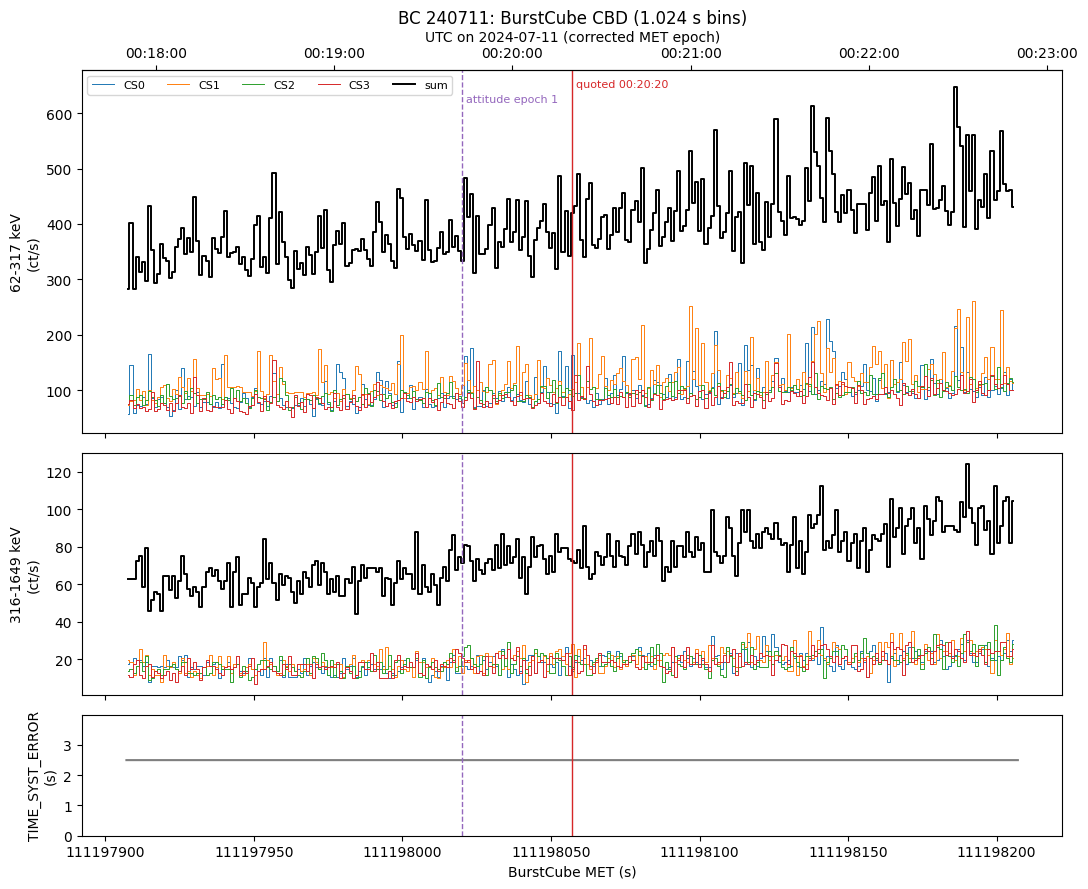

In [13]:
bc_span = covered_span(bc_cbds, bc_t0, 150.0)
print(f'_cl coverage used: {bc_span[0]-bc_t0:+.0f} to {bc_span[1]-bc_t0:+.0f} s')
edges = np.arange(bc_span[0], bc_span[1], 1.024)
soft = coarse_rates(bc_cbds, edges, SOFT)
hard = coarse_rates(bc_cbds, edges, HARD)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, height_ratios=(3, 2, 1))
plot_bands(axes[:2], edges, soft, hard)
plot_syst_error(axes[2], bc_cbds, bc_span)
mark(axes, bc_t0, 'quoted 00:20:20', color='C3', lw=1.0)
mark(axes, att1, 'attitude epoch 1', row=1, color='C4', lw=1.0, ls='--')
axes[0].set_title('BC 240711: BurstCube CBD (1.024 s bins)', pad=34)
finish_met_axis(axes[-1])
add_utc_axis(axes[0])
fig.tight_layout()
plt.show()

Is there anything at either instant? The cell below lists the largest
native 0.256 s bins of the soft-band sum across the window, measured against
the actual scatter of the bins rather than the Poisson expectation, since the
two differ here. At native resolution nothing depends on where coarse bin
edges happen to fall.

In [14]:
ref = bc_cbds['CS0'].data
rel = 0.5 * (ref.tstart + ref.tstop) - bc_t0
window = (rel > -70.0) & (rel < 20.0)
soft_counts = sum(bc_cbds[det].data.counts[window][:, SOFT].sum(axis=1) for det in DETECTORS)
median, scatter = np.median(soft_counts), np.std(soft_counts)

print(f'{window.sum()} native bins from -70 to +20 s: median {median:.0f} counts, '
     f'scatter {scatter:.1f} (counting statistics alone: {np.sqrt(median):.1f})')
print('the six largest bins:')
for k in np.argsort(soft_counts)[::-1][:6]:
    print(f'   {rel[window][k]:+7.2f} s : {soft_counts[k]:.0f} counts '
         f'({(soft_counts[k] - median) / scatter:+.1f}x the scatter)')
print(f'\nfor reference: quoted 00:20:20 is at 0 s, attitude epoch 1 at {att1 - bc_t0:+.1f} s')

352 native bins from -70 to +20 s: median 92 counts, scatter 23.4 (counting statistics alone: 9.6)
the six largest bins:
    -58.37 s : 203 counts (+4.7x the scatter)
    -33.53 s : 203 counts (+4.7x the scatter)
    -36.09 s : 196 counts (+4.4x the scatter)
     +1.79 s : 194 counts (+4.4x the scatter)
    -56.83 s : 185 counts (+4.0x the scatter)
    -18.69 s : 179 counts (+3.7x the scatter)

for reference: quoted 00:20:20 is at 0 s, attitude epoch 1 at -37.0 s


Spikes of about the same size turn up across the whole window: near both
marked instants, but just as much well away from either. And the scatter
itself is more than twice what counting statistics alone would give. Nothing
singles out either instant. These light curves neither confirm the candidate
nor choose between 00:20:20 and 00:19:43.

Note the `TIME_SYST_ERROR` panel: on this day the ground reconstruction
shifts every bin by over four minutes, and quotes 2.5 s for it -- a figure
the README's *`TIME_SYST_ERROR` is underestimated in at least some periods*
caveat says to treat as a lower bound.

## Summary

* Attitude epochs 1 and 2 are the reconstructions made for these two events.
  Epoch 2 falls within a few seconds of GBM's flare trigger on the corrected
  epoch.
* **SFL 240714** is seen by GBM (`SFLARE`) as enormous thermal emission below
  50 keV plus a short non-thermal burst at 50-300 keV. BurstCube, with its
  ~62 keV threshold, sees only the non-thermal burst: a modest bump in its
  62-316 keV band at the same time as GBM's, and nothing obvious above
  316 keV. GBM's detectors are swamped during the thermal peak; those bins
  are masked from GBM's own livetime, not plotted as dips.
  The non-thermal burst peaks in GBM n3's 50-296 keV band about 109 s after
  the trigger, at 02:31:09.7 UTC (BurstCube MET 111465106.65); n5's
  livetime collapses before the peak, so it cannot place it.
* The flare lines up with GBM near zero lag and not at +/-37 s -- a second,
  independent confirmation of the corrected MET epoch, though too broad to
  measure a few-second residual.
* **BC 240711** has no GBM trigger to compare with. Its soft-band light
  curve is spiky throughout, with spikes of similar size near both candidate
  instants and away from them, so these light curves neither confirm the
  candidate nor choose between 00:20:20 and 00:19:43.
* On 240711 the detectors were still on their low thresholds, so CBD
  channels 0-1 are populated that day, with over a hundred times the
  Poisson variance. Both events are shown above ~62 keV so they can be
  compared on the same footing; even there, `CS0` and `CS1` scatter several
  times more than Poisson on 240711.